In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from analysis import *

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

pitchbook_results_dirs = ['../pitchbook/part2_eval/part2_eval/trial_1_results', '../pitchbook/part2_eval/part2_eval/trial_2_results', '../pitchbook/part2_eval/part2_eval/trial_3_results', '../pitchbook/part2_eval/part2_eval/trial_4_results']
pitchbook_var_file_paths = [ '../pitchbook/variables_by_difficulty.json'] * 5
pitchbook_baseline_file_paths = ['../pitchbook/baselines_by_var.json'] * 5
pitchbook_datasets = ['pitchbook'] * 5
pitchbook_var_file = pitchbook_var_file_paths[0]
pitchbook_results = aggregate_results('pitchbook', pitchbook_results_dirs, pitchbook_var_file_paths, pitchbook_datasets, pitchbook_baseline_file_paths)
pitchbook_results['trial'] = pitchbook_results['trial'].astype(str)

nhanes_results_dirs = [ '../nhanes/part2_eval/part2_eval/trial_0_results', '../nhanes/part2_eval/part2_eval/trial_1_results', '../nhanes/part2_eval/part2_eval/trial_2_results', '../nhanes/part2_eval/part2_eval/trial_3_results', '../nhanes/part2_eval/part2_eval/trial_4_results']
nhanes_var_file_paths = [ '../nhanes/variables_by_difficulty.json'] * 5
nhanes_baseline_file_paths = ['../nhanes/baselines_by_var.json'] * 5
nhanes_datasets = ['nhanes'] * 5
nhanes_var_file = nhanes_var_file_paths[0]
nhanes_results = aggregate_results('nhanes', nhanes_results_dirs, nhanes_var_file_paths, nhanes_datasets, nhanes_baseline_file_paths)
nhanes_results['trial'] = nhanes_results['trial'].astype(str)

glassdoor_results_dirs = [ '../glassdoor/part2_eval/part2_eval/trial_0_results', '../glassdoor/part2_eval/part2_eval/trial_1_results', '../glassdoor/part2_eval/part2_eval/trial_2_results', '../glassdoor/part2_eval/part2_eval/trial_3_results', '../glassdoor/part2_eval/part2_eval/trial_4_results']
glassdoor_var_file_paths = [ '../glassdoor/variables_by_difficulty.json'] * 5
glassdoor_baseline_file_paths = ['../glassdoor/baselines_by_var.json'] * 5
glassdoor_datasets = ['glassdoor'] * 5
glassdoor_var_file = glassdoor_var_file_paths[0]
glassdoor_results = aggregate_results('glassdoor', glassdoor_results_dirs, glassdoor_var_file_paths, glassdoor_datasets, glassdoor_baseline_file_paths)
glassdoor_results['trial'] = glassdoor_results['trial'].astype(str)

# Define baseline configuration (most common or default values)
baseline_config_reasoning = {
    'model': 'o4-mini',  
    'sysprompt': 'base',
    'protocol': 'direct', 
    'temperature': 'medium'
}

baseline_config_regular = {
    'model': 'gpt-4o',
    'sysprompt': 'base',
    'protocol': 'direct',
    'temperature': 'medium'
}

def extract_experiment_info(approach):
    """Extract system prompt, temperature, and protocol from approach name
    
    Expected format: EXPERTS-nhanes_{model}_{sysprompt}_temp{temp}_experts-VARIABLES-{variables}-PROTOCOL-{protocol}-TEMP-{temp}
    """
    parts = approach.split('_')
    
    # Extract model
    model = parts[0]

    # Extract system prompt
    sysprompt = 'base'  # default
    if 'superforecaster' in approach:
        sysprompt = 'superforecaster'
    elif 'conservative' in approach:
        sysprompt = 'conservative'
    
    # Extract protocol
    protocol = 'direct'  # default
    if 'quantile' in approach:
        protocol = 'quantile'
    elif 'mean-variance' in approach or ('mean' in approach and 'variance' in approach):
        protocol = 'mean-variance'
    
    # Extract temperature
    temperature = 'medium'  # default
    if 'temphigh' in approach or 'temp_high' in approach or 'high' in approach or '1.0' in approach:
        temperature = 'high'
    elif 'templow' in approach or 'temp_low' in approach or 'low' in approach or '0.2' in approach:
        temperature = 'low'
    elif 'tempmedium' in approach or 'temp_medium' in approach or 'medium' in approach or '0.5' in approach:
        temperature = 'medium'
    
    return {
        'model': model,
        'sysprompt': sysprompt,
        'protocol': protocol,
        'temperature': temperature
    }

# Extract experiment info for each approach
nhanes_experiment_info = nhanes_results['approach'].apply(extract_experiment_info)
glassdoor_experiment_info = glassdoor_results['approach'].apply(extract_experiment_info)
pitchbook_experiment_info = pitchbook_results['approach'].apply(extract_experiment_info)

for key in ['model', 'sysprompt', 'protocol', 'temperature']:
    nhanes_results[key] = nhanes_experiment_info.apply(lambda x: x[key])
    glassdoor_results[key] = glassdoor_experiment_info.apply(lambda x: x[key])
    pitchbook_results[key] = pitchbook_experiment_info.apply(lambda x: x[key])

['EXPERTS-pitchbook_gpt-4o_superforecaster_temp0.5_experts-VARIABLES-variables_by_difficulty-PROTOCOL-direct-TEMP-0.5', 'EXPERTS-pitchbook_o4-mini_conservative_tempmedium_experts-VARIABLES-variables_by_difficulty-PROTOCOL-direct-TEMP-medium', 'EXPERTS-pitchbook_o4-mini_base_temphigh_experts-VARIABLES-variables_by_difficulty-PROTOCOL-direct-TEMP-high', 'EXPERTS-pitchbook_o4-mini_base_tempmedium_experts-VARIABLES-variables_by_difficulty-PROTOCOL-direct-TEMP-medium', 'EXPERTS-pitchbook_o4-mini_superforecaster_tempmedium_experts-VARIABLES-variables_by_difficulty-PROTOCOL-direct-TEMP-medium', 'EXPERTS-pitchbook_o4-mini_base_tempmedium_experts-VARIABLES-variables_by_difficulty-PROTOCOL-quantile-TEMP-medium', 'EXPERTS-pitchbook_gpt-4o_conservative_temp0.5_experts-VARIABLES-variables_by_difficulty-PROTOCOL-direct-TEMP-0.5', 'EXPERTS-pitchbook_o4-mini_base_templow_experts-VARIABLES-variables_by_difficulty-PROTOCOL-direct-TEMP-low', 'EXPERTS-pitchbook_o4-mini_base_tempmedium_experts-VARIABLES-va

/home/ubuntu/openestimate/.venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/ubuntu/openestimate/.venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


Row:  variable_name                     The average midpoint of the posted salary rang...
variable                                                                     easy_1
ground_truth                                                               115400.0
ground_truth_distribution_type                                               normal
mean                                                                       113000.0
std                                                                             0.0
temperature                                                                     NaN
variables_file                                                                  NaN
sysprompt_type                                                                  NaN
elicitation_protocol                                                            NaN
model                                                                           NaN
convo_file_path                                                       

/home/ubuntu/openestimate/.venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2087: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/home/ubuntu/openestimate/.venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2087: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/home/ubuntu/openestimate/.venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2087: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/home/ubuntu/openestimate/.venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2087: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/home/ubuntu/openestimate/.venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2087: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scal

Results saved to: glassdoor_combined_processed_results.csv


## Results Integrity Check

In [2]:
signal_col = "mean"          

print("\nNHANES")
completion_stats = (
    nhanes_results
        .assign(answered=nhanes_results[signal_col].notna())   # True / False per row
        .groupby(['approach', 'trial'])['answered']     # group then take boolean col
        .mean()                                         # fraction answered
        .mul(100)                                       # convert to %
        .reset_index(name='completion_rate')            # nice tidy frame
)

print("\nCompletion-rate by model & trial (%):")
print("\nApproach                                  Trial    Completion %")
print("-" * 65)
for _, row in completion_stats.sort_values(['approach', 'trial']).iterrows():
    if row['completion_rate'] < 100:
        print(f"{row['approach']:<40} {row['trial']:<8} {row['completion_rate']:>8.1f}")

print("\nPitchbook")
completion_stats = (
    pitchbook_results
        .assign(answered=pitchbook_results[signal_col].notna())   # True / False per row
        .groupby(['approach', 'trial'])['answered']     # group then take boolean col
        .mean()                                         # fraction answered
        .mul(100)                                       # convert to %
        .reset_index(name='completion_rate')            # nice tidy frame
)

print("\nCompletion-rate by model & trial (%):")
print("\nApproach                                  Trial    Completion %")
print("-" * 65)
for _, row in completion_stats.sort_values(['approach', 'trial']).iterrows():
    if row['completion_rate'] < 100:
        print(f"{row['approach']:<40} {row['trial']:<8} {row['completion_rate']:>8.1f}")      


print("\nGlassdoor")
completion_stats = (
    glassdoor_results
        .assign(answered=glassdoor_results[signal_col].notna())   # True / False per row
        .groupby(['approach', 'trial'])['answered']     # group then take boolean col
        .mean()                                         # fraction answered
        .mul(100)                                       # convert to %
        .reset_index(name='completion_rate')            # nice tidy frame
)

print("\nCompletion-rate by model & trial (%):")
print("\nApproach                                  Trial    Completion %")
print("-" * 65)
for _, row in completion_stats.sort_values(['approach', 'trial']).iterrows():
    if row['completion_rate'] < 100:
        print(f"{row['approach']:<40} {row['trial']:<8} {row['completion_rate']:>8.1f}")


NHANES

Completion-rate by model & trial (%):

Approach                                  Trial    Completion %
-----------------------------------------------------------------
o4-mini_base_direct_temphigh             0            95.9
o4-mini_base_direct_temphigh             1            98.6
o4-mini_base_direct_temphigh             2            95.9
o4-mini_base_direct_temphigh             3            87.8
o4-mini_base_direct_temphigh             4            97.3
o4-mini_base_direct_templow              0            97.3
o4-mini_base_direct_templow              2            98.6
o4-mini_base_direct_tempmedium           1            98.6
o4-mini_base_direct_tempmedium           4            98.6
o4-mini_conservative_direct_tempmedium   4            98.6
o4-mini_superforecaster_direct_tempmedium 0            97.3
o4-mini_superforecaster_direct_tempmedium 1            98.6
o4-mini_superforecaster_direct_tempmedium 4            98.6

Pitchbook

Completion-rate by model & trial (%):

A

In [3]:
def compute_ece_for_group(group_data):
    """Compute ECE for a group of data across trials"""
    # Calculate percentage of ground truths in each quartile for each trial
    quartile_counts_by_trial = group_data.groupby('trial')['quartile_of_gt'].value_counts(normalize=True) * 100
    quartile_df_by_trial = quartile_counts_by_trial.unstack(fill_value=0)
    
    # Ensure all quartiles are present
    for quartile in [1, 2, 3, 4]:
        if quartile not in quartile_df_by_trial.columns:
            quartile_df_by_trial[quartile] = 0
    
    # Calculate ECE for each trial (deviation from perfect 25% for each quartile)
    ece_by_trial = []
    for trial in quartile_df_by_trial.index:
        trial_ece = 0
        for quartile in [1, 2, 3, 4]:
            # Expected percentage is 25% for each quartile
            expected_pct = 25.0
            actual_pct = quartile_df_by_trial.loc[trial, quartile]
            trial_ece += abs(actual_pct - expected_pct)
        
        # ECE is the average absolute deviation across quartiles
        ece_by_trial.append(trial_ece / 4.0)
    
    # Return ECE statistics across trials
    ece_array = np.array(ece_by_trial)
    return {
        'ece_mean': ece_array.mean(),
        'ece_std': ece_array.std(),
        'ece_se': ece_array.std() / np.sqrt(len(ece_array)) if len(ece_array) > 1 else 0,
        'n_trials': len(ece_array)
    }


def compute_ece_by_groupings(results, baseline_config):
    """Compute ECE by different groupings while holding other variables constant
    
    Args:
        results: DataFrame with experimental results
        baseline_config: Dict specifying which values to hold constant for other variables
                        e.g., {'model': 'o4-mini', 'sysprompt': 'base', 'protocol': 'direct', 'temperature': 'medium'}
    """
    
    results_copy = results.copy()
    
    # Extract experiment info for each approach
    groupings = {}
    
    # 1. Vary system prompt while holding everything else constant
    sysprompt_subset = results_copy[
        (results_copy['model'] == baseline_config['model']) &
        (results_copy['protocol'] == baseline_config['protocol']) &
        (results_copy['temperature'] == baseline_config['temperature'])
    ]
    print(f"ECE Sysprompt subset size: {len(sysprompt_subset)}")
    
    sysprompt_groups = sysprompt_subset.groupby('sysprompt')
    sysprompt_results = []
    for sysprompt, group_data in sysprompt_groups:
        ece_stats = compute_ece_for_group(group_data)
        ece_stats['group'] = sysprompt
        ece_stats['category'] = 'System Prompt'
        sysprompt_results.append(ece_stats)
    groupings['sysprompt'] = pd.DataFrame(sysprompt_results)

    # Normalize by baseline (default) ECE value
    baseline_ece = None
    for _, row in groupings['sysprompt'].iterrows():
        if row['group'] == baseline_config['sysprompt']:
            baseline_ece = row['ece_mean']
            break
    
    # Normalize all ECE values by the baseline
    groupings['sysprompt']['ece_mean'] = groupings['sysprompt']['ece_mean'] / baseline_ece

    
    # 2. Vary temperature while holding everything else constant
    temperature_subset = results_copy[
        (results_copy['model'] == baseline_config['model']) &
        (results_copy['sysprompt'] == baseline_config['sysprompt']) &
        (results_copy['protocol'] == baseline_config['protocol'])
    ]
    print(f"ECE Temperature subset size: {len(temperature_subset)}")
    
    temperature_groups = temperature_subset.groupby('temperature')
    temperature_results = []
    for temperature, group_data in temperature_groups:
        ece_stats = compute_ece_for_group(group_data)
        ece_stats['group'] = temperature
        ece_stats['category'] = 'Temperature'
        temperature_results.append(ece_stats)
    groupings['temperature'] = pd.DataFrame(temperature_results)

     # Normalize by baseline (default) ECE value
    baseline_ece = None
    for _, row in groupings['temperature'].iterrows():
        if row['group'] == baseline_config['temperature']:
            baseline_ece = row['ece_mean']
            break
    
    # Normalize all ECE values by the baseline
    groupings['temperature']['ece_mean'] = groupings['temperature']['ece_mean'] / baseline_ece
    
    # 3. Vary protocol while holding everything else constant
    protocol_subset = results_copy[
        (results_copy['model'] == baseline_config['model']) &
        (results_copy['sysprompt'] == baseline_config['sysprompt']) &
        (results_copy['temperature'] == baseline_config['temperature'])
    ]
    print(f"ECE Protocol subset size: {len(protocol_subset)}")

    protocol_groups = protocol_subset.groupby('protocol')
    protocol_results = []
    for protocol, group_data in protocol_groups:
        ece_stats = compute_ece_for_group(group_data)
        ece_stats['group'] = protocol
        ece_stats['category'] = 'Protocol'
        protocol_results.append(ece_stats)
    groupings['protocol'] = pd.DataFrame(protocol_results)

    # Normalize by baseline (default) ECE value
    baseline_ece = None
    for _, row in groupings['protocol'].iterrows():
        if row['group'] == baseline_config['protocol']:
            baseline_ece = row['ece_mean']
            break
    
    # Normalize all ECE values by the baseline
    groupings['protocol']['ece_mean'] = groupings['protocol']['ece_mean'] / baseline_ece
    
    return groupings

ECE Sysprompt subset size: 1110


ECE Temperature subset size: 1110
ECE Protocol subset size: 1110
ECE Sysprompt subset size: 1110
ECE Temperature subset size: 1110
ECE Protocol subset size: 1110
ECE Sysprompt subset size: 732
ECE Temperature subset size: 732
ECE Protocol subset size: 732
ECE Sysprompt subset size: 732
ECE Temperature subset size: 732
ECE Protocol subset size: 732
ECE Sysprompt subset size: 645
ECE Temperature subset size: 645
ECE Protocol subset size: 645
ECE Sysprompt subset size: 645
ECE Temperature subset size: 645
ECE Protocol subset size: 645


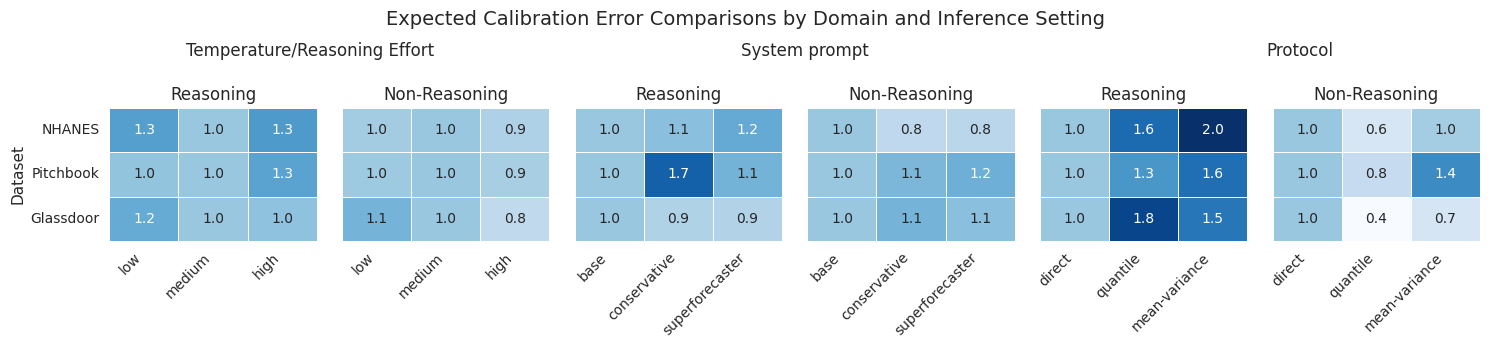

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define baseline configurations (same as before)
baseline_config_reasoning = {
    'model': 'o4-mini',  
    'sysprompt': 'base',
    'protocol': 'direct', 
    'temperature': 'medium'
}

baseline_config_regular = {
    'model': 'gpt-4o',
    'sysprompt': 'base',
    'protocol': 'direct',
    'temperature': 'medium'
}

# Helper function to extract ECE values from groupings
def extract_group_ece(groupings, key, levels):
    vals = {lvl: np.nan for lvl in levels}
    if key in groupings and len(groupings[key]) > 0:
        df = groupings[key].copy()
        df['group_norm'] = (
            df['group'].astype(str).str.strip().str.lower().str.replace('_', '-', regex=False)
        )
        for _, row in df.iterrows():
            g = row['group_norm']
            if g in vals:
                vals[g] = float(row['ece_mean'])
    return vals

def df_from_levels_ece(grp_r, grp_nr, key, levels, row_index):
    r_df = pd.DataFrame(
        [extract_group_ece(grp_r[i], key, levels) for i in range(3)],
        index=row_index
    )[levels]
    nr_df = pd.DataFrame(
        [extract_group_ece(grp_nr[i], key, levels) for i in range(3)],
        index=row_index
    )[levels]
    return r_df, nr_df

# Compute ECE groupings for all datasets
nhanes_ece_r = compute_ece_by_groupings(nhanes_results.copy(), baseline_config_reasoning)
nhanes_ece_nr = compute_ece_by_groupings(nhanes_results.copy(), baseline_config_regular)
pitch_ece_r = compute_ece_by_groupings(pitchbook_results.copy(), baseline_config_reasoning)
pitch_ece_nr = compute_ece_by_groupings(pitchbook_results.copy(), baseline_config_regular)
glass_ece_r = compute_ece_by_groupings(glassdoor_results.copy(), baseline_config_reasoning)
glass_ece_nr = compute_ece_by_groupings(glassdoor_results.copy(), baseline_config_regular)

grp_r_ece = [nhanes_ece_r, pitch_ece_r, glass_ece_r]
grp_nr_ece = [nhanes_ece_nr, pitch_ece_nr, glass_ece_nr]
rows = ['NHANES', 'Pitchbook', 'Glassdoor']

# Build matrices for each factor
temp_levels = ['low', 'medium', 'high']
sp_levels = ['base', 'conservative', 'superforecaster']
prot_levels = ['direct', 'quantile', 'mean-variance']

temp_r_ece, temp_nr_ece = df_from_levels_ece(grp_r_ece, grp_nr_ece, 'temperature', temp_levels, rows)
sp_r_ece, sp_nr_ece = df_from_levels_ece(grp_r_ece, grp_nr_ece, 'sysprompt', sp_levels, rows)
prot_r_ece, prot_nr_ece = df_from_levels_ece(grp_r_ece, grp_nr_ece, 'protocol', prot_levels, rows)

# Shared color scale across all six heatmaps
all_vals_ece = pd.concat([
    temp_r_ece.stack(), temp_nr_ece.stack(),
    sp_r_ece.stack(), sp_nr_ece.stack(),
    prot_r_ece.stack(), prot_nr_ece.stack()
]).dropna()
vmin_ece, vmax_ece = (all_vals_ece.min(), all_vals_ece.max()) if len(all_vals_ece) else (0, 1)

# Use the same styling as MAE plots
monochrome = plt.cm.Blues

def draw_ece(ax, df, title, xlabel, show_y=False, show_xlabel=True):
    sns.heatmap(df, ax=ax, cmap=monochrome, vmin=vmin_ece, vmax=vmax_ece,
                annot=True, fmt='.1f', cbar=False, linewidths=0.5)  # fmt='.1f' for ECE values
    ax.set_title(title)
    if show_xlabel:
        ax.set_xlabel(xlabel)
    else:
        ax.set_xlabel('')
    if show_y:
        ax.set_ylabel('Dataset')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Create the ECE comparison plot
fig, axes = plt.subplots(1, 6, figsize=(15, 3.5))

draw_ece(axes[0], temp_r_ece,  'Reasoning',     '', show_y=True, show_xlabel=False)
draw_ece(axes[1], temp_nr_ece, 'Non-Reasoning', '', show_xlabel=False)
draw_ece(axes[2], sp_r_ece,    'Reasoning',     '', show_xlabel=False)
draw_ece(axes[3], sp_nr_ece,   'Non-Reasoning', '', show_xlabel=False)
draw_ece(axes[4], prot_r_ece,  'Reasoning',     '', show_xlabel=False)
draw_ece(axes[5], prot_nr_ece, 'Non-Reasoning', '', show_xlabel=False)

# Add main title and section labels
fig.suptitle('Expected Calibration Error Comparisons by Domain and Inference Setting', 
             fontsize=14, y=0.98)

fig.text(0.21, 0.85, 'Temperature/Reasoning Effort', ha='center', fontsize=12)      
fig.text(0.54, 0.85, 'System prompt', ha='center', fontsize=12)     
fig.text(0.87, 0.85, 'Protocol', ha='center', fontsize=12)        

plt.tight_layout()
plt.subplots_adjust(top=0.70)
plt.show()

FACTOR temperature
FACTOR sysprompt
FACTOR protocol


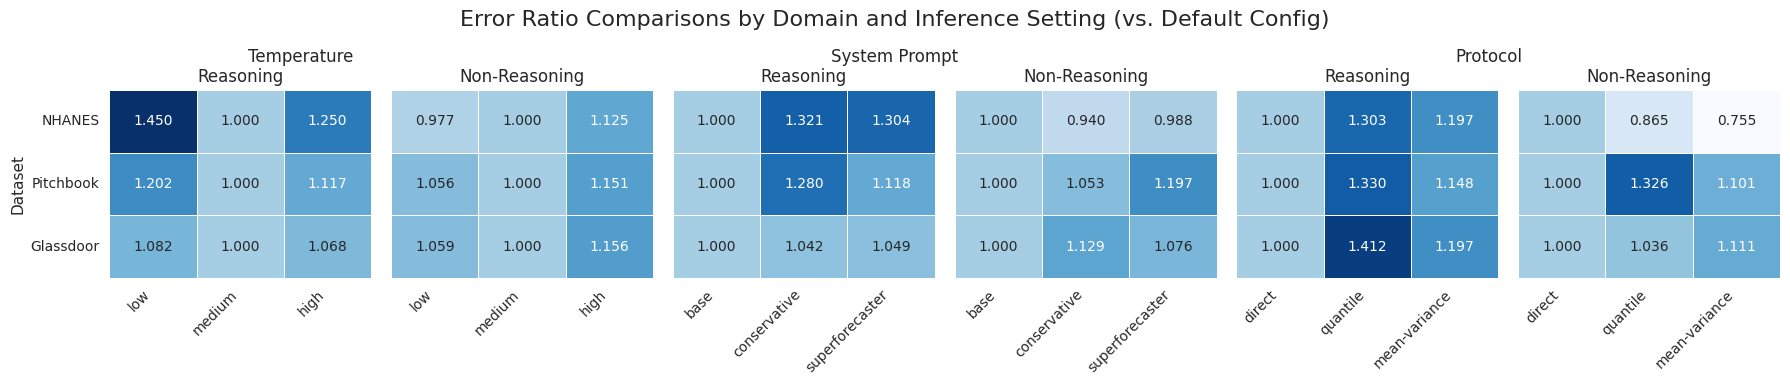

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def compute_error_ratios_by_groupings(results, baseline_config):
    """
    Compute error ratios relative to the default model configuration.
    
    Error ratio = (group MAE per variable) / (default config MAE per variable),
    then aggregated across variables.
    """
    df = results.copy()

    # Create baseline mask using the provided baseline_config
    baseline_mask = (
        (df['model'] == baseline_config['model']) & 
        (df['sysprompt'] == baseline_config['sysprompt']) & 
        (df['temperature'] == baseline_config['temperature']) & 
        (df['protocol'] == baseline_config['protocol'])
    )
    
    # Get baseline data using the default model configuration
    baseline_data = df[baseline_mask]
    
    if baseline_data.empty:
        empty_result = pd.DataFrame(columns=['group', 'ratio_mean', 'ratio_std', 'n_trials', 'ratio_se', 'category'])
        return {factor: empty_result.copy() for factor in ['sysprompt', 'temperature', 'protocol']}

    # Calculate baseline MAE per variable (mean across all trials for each variable)
    baseline_mae_by_var = baseline_data.groupby('variable')['abs_error'].mean()

    def calculate_ratios(group_column, data_mask, category_label):
        """Calculate error ratios for a specific grouping factor (matching your method)."""
        subset = df[data_mask]
        
        if subset.empty:
            result = pd.DataFrame(columns=['group', 'ratio_mean', 'ratio_std', 'n_trials', 'ratio_se'])
            result['category'] = category_label
            return result

        # Get unique groups
        groups = subset[group_column].unique()
        group_results = []
        
        for group in groups:
            group_data = subset[subset[group_column] == group]
            
            if group_data.empty:
                continue
                
            # Calculate MAE per variable for this group (matching your approach)
            group_mae_by_var = group_data.groupby('variable')['abs_error'].mean()
            
            # Calculate ratio per variable (matching your method)
            ratio_by_var = group_mae_by_var / baseline_mae_by_var.reindex(group_mae_by_var.index)
            
            # Drop NaN ratios
            valid_ratios = ratio_by_var.dropna().values
            
            if len(valid_ratios) == 0:
                continue
                
            # Aggregate across variables (matching your approach)
            mean_ratio = np.nanmean(valid_ratios)
            std_ratio = np.nanstd(valid_ratios, ddof=1) if len(valid_ratios) > 1 else 0.0
            n_vars = len(valid_ratios)
            se_ratio = std_ratio / np.sqrt(n_vars) if n_vars > 0 else 0.0
            
            group_results.append({
                'group': group,
                'ratio_mean': mean_ratio,
                'ratio_std': std_ratio,
                'n_trials': n_vars,  # This represents number of variables, not trials
                'ratio_se': se_ratio,
                'category': category_label
            })
        
        return pd.DataFrame(group_results) if group_results else pd.DataFrame(
            columns=['group', 'ratio_mean', 'ratio_std', 'n_trials', 'ratio_se', 'category']
        )

    # Define masks for each factor (holding others at baseline while varying one factor)
    factor_masks = {
        'sysprompt': (
            (df['model'] == baseline_config['model']) & 
            (df['protocol'] == baseline_config['protocol']) & 
            (df['temperature'] == baseline_config['temperature'])
            # sysprompt varies
        ),
        'temperature': (
            (df['model'] == baseline_config['model']) & 
            (df['sysprompt'] == baseline_config['sysprompt']) & 
            (df['protocol'] == baseline_config['protocol'])
            # temperature varies
        ),
        'protocol': (
            (df['model'] == baseline_config['model']) & 
            (df['sysprompt'] == baseline_config['sysprompt']) & 
            (df['temperature'] == baseline_config['temperature'])
            # protocol varies
        )
    }

    # Calculate ratios for each factor
    results = {}
    factor_labels = {
        'sysprompt': 'System Prompt',
        'temperature': 'Temperature', 
        'protocol': 'Protocol'
    }
    
    for factor, mask in factor_masks.items():
        results[factor] = calculate_ratios(factor, mask, factor_labels[factor])

    return results


def extract_group_ratios(groupings_dict, factor, expected_levels):
    """Extract ratio values for specified levels, filling missing with NaN."""
    ratio_values = {level: np.nan for level in expected_levels}
    
    if factor not in groupings_dict or groupings_dict[factor].empty:
        return ratio_values
    
    factor_data = groupings_dict[factor].copy()
    factor_data['normalized_group'] = (
        factor_data['group'].astype(str)
        .str.strip()
        .str.lower()
        .str.replace('_', '-', regex=False)
    )
    
    for _, row in factor_data.iterrows():
        normalized_group = row['normalized_group']
        if normalized_group in ratio_values:
            ratio_values[normalized_group] = float(row['ratio_mean'])
    
    return ratio_values


def create_factor_dataframes(reasoning_groupings, non_reasoning_groupings, factor, levels, datasets):
    """Create DataFrames for reasoning and non-reasoning conditions."""
    reasoning_df = pd.DataFrame([
        extract_group_ratios(groupings, factor, levels) 
        for groupings in reasoning_groupings
    ], index=datasets)[levels]
    
    non_reasoning_df = pd.DataFrame([
        extract_group_ratios(groupings, factor, levels) 
        for groupings in non_reasoning_groupings
    ], index=datasets)[levels]
    
    return reasoning_df, non_reasoning_df


def create_heatmap_subplot(ax, data, title, xlabel='', show_ylabel=False, show_xlabel=True, 
                          colormap=None, vmin=None, vmax=None):
    """Create a single heatmap subplot with consistent formatting."""
    sns.heatmap(data, ax=ax, cmap=colormap, vmin=vmin, vmax=vmax,
                annot=True, fmt='.3f', cbar=False, linewidths=0.5)
    
    ax.set_title(title)
    ax.set_xlabel(xlabel if show_xlabel else '')
    
    if show_ylabel:
        ax.set_ylabel('Dataset')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    


def plot_error_ratio_heatmaps(reasoning_groupings, non_reasoning_groupings, datasets):
    """Create comprehensive error ratio heatmaps."""
    
    # Define factor levels
    factor_configs = {
        'temperature': ['low', 'medium', 'high'],
        'sysprompt': ['base', 'conservative', 'superforecaster'],
        'protocol': ['direct', 'quantile', 'mean-variance']
    }
    
    # Create DataFrames for each factor
    factor_dataframes = {}
    for factor, levels in factor_configs.items():
        reasoning_df, non_reasoning_df = create_factor_dataframes(
            reasoning_groupings, non_reasoning_groupings, factor, levels, datasets
        )
        factor_dataframes[factor] = {
            'reasoning': reasoning_df,
            'non_reasoning': non_reasoning_df
        }
    
    # Determine shared color scale
    all_values = pd.concat([
        df for factor_data in factor_dataframes.values() 
        for df in factor_data.values()
    ]).values.flatten()
    all_values = all_values[~np.isnan(all_values)]
    
    if len(all_values) > 0:
        vmin, vmax = all_values.min(), all_values.max()
    else:
        vmin, vmax = 0, 1
    
    # Create colormap
    colormap = plt.cm.Blues
    
    # Create plot
    fig, axes = plt.subplots(1, 6, figsize=(18, 4))
    
    factor_titles = ['Temperature', 'System Prompt', 'Protocol']
    

    subplots = {}
    # Plot each factor
    for i, (factor, title) in enumerate(zip(factor_configs.keys(), factor_titles)):
        reasoning_ax = axes[i * 2]
        non_reasoning_ax = axes[i * 2 + 1]
        print("FACTOR", factor)
        # Reasoning subplot
        create_heatmap_subplot(
            reasoning_ax, 
            factor_dataframes[factor]['reasoning'],
            'Reasoning',
            show_ylabel=(i == 0),
            show_xlabel=False,
            colormap=colormap,
            vmin=vmin,
            vmax=vmax
        )
        
        # Non-reasoning subplot
        create_heatmap_subplot(
            non_reasoning_ax,
            factor_dataframes[factor]['non_reasoning'], 
            'Non-Reasoning',
            show_ylabel=False,
            show_xlabel=False,
            colormap=colormap,
            vmin=vmin,
            vmax=vmax
        )
        subplots[factor] = {
            'reasoning': factor_dataframes[factor]['reasoning'],
            'non_reasoning': factor_dataframes[factor]['non_reasoning']
        }
    
    # Add titles and formatting
    fig.suptitle('Error Ratio Comparisons by Domain and Inference Setting (vs. Default Config)', 
                 fontsize=16, y=0.95)
    
    # Add section labels
    section_positions = [0.17, 0.50, 0.83]
    for pos, title in zip(section_positions, factor_titles):
        fig.text(pos, 0.82, title, ha='center', fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.75)
    plt.show()
    return subplots

# Main execution function
def analyze_error_ratios(datasets_dict, baseline_configs, dataset_names):
    """
    Main function to analyze error ratios across datasets and conditions.
    
    Parameters:
    - datasets_dict: dict with 'reasoning' and 'non_reasoning' keys, each containing list of datasets
    - baseline_configs: dict with 'reasoning' and 'non_reasoning' baseline configurations  
    - dataset_names: list of dataset names for labeling
    """
    
    # Filter out Llama 8B models from model column (not approach column)
    def filter_llama_8b_model(df):
        return df[~df['model'].str.contains('meta-llama-3-8b', case=False, na=False)].copy()
    
    reasoning_datasets = [filter_llama_8b_model(df) for df in datasets_dict['reasoning']]
    non_reasoning_datasets = [filter_llama_8b_model(df) for df in datasets_dict['non_reasoning']]
    
    # Compute groupings
    reasoning_groupings = [
        compute_error_ratios_by_groupings(df, baseline_configs['reasoning']) 
        for df in reasoning_datasets
    ]
    
    non_reasoning_groupings = [
        compute_error_ratios_by_groupings(df, baseline_configs['non_reasoning']) 
        for df in non_reasoning_datasets
    ]
    
    # Create visualizations
    subplots = plot_error_ratio_heatmaps(reasoning_groupings, non_reasoning_groupings, dataset_names)
    
    return reasoning_groupings, non_reasoning_groupings, subplots

# Define your datasets and configurations
datasets = {
    'reasoning': [nhanes_results, pitchbook_results, glassdoor_results],
    'non_reasoning': [nhanes_results, pitchbook_results, glassdoor_results]
}

# Example baseline configurations (default model settings)
baselines = {
    'reasoning': {
        'model': 'o4-mini',
        'sysprompt': 'base', 
        'temperature': 'medium',
        'protocol': 'direct'
    },
    'non_reasoning': {
        'model': 'gpt-4o',
        'sysprompt': 'base',
        'temperature': 'medium', 
        'protocol': 'direct'
    }
}

dataset_names = ['NHANES', 'Pitchbook', 'Glassdoor']

# Run analysis
reasoning_results, non_reasoning_results, error_subplots = analyze_error_ratios(
    datasets, baselines, dataset_names
)

In [6]:
# Preprocess log probs so that they're never less than -5
pitchbook_results['ground_truth_log_prob'] = pitchbook_results['ground_truth_log_prob'].clip(lower=-5)
nhanes_results['ground_truth_log_prob'] = nhanes_results['ground_truth_log_prob'].clip(lower=-5)
glassdoor_results['ground_truth_log_prob'] = glassdoor_results['ground_truth_log_prob'].clip(lower=-5)

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define baseline configurations (same as before)
baseline_config_reasoning = {
    'model': 'o4-mini',  
    'sysprompt': 'base',
    'protocol': 'direct', 
    'temperature': 'medium'
}

baseline_config_regular = {
    'model': 'gpt-4o',
    'sysprompt': 'base',
    'protocol': 'direct',
    'temperature': 'medium'
}

def compute_logprob_for_group(group_data):
    """Compute log probability statistics for a group of data across trials"""
    # Calculate mean log probability for each trial
    logprob_by_trial = []
    for trial in group_data['trial'].unique():
        trial_data = group_data[group_data['trial'] == trial]
        if 'ground_truth_log_prob' in trial_data.columns:
            # Calculate mean log probability for this trial
            mean_logprob = trial_data['ground_truth_log_prob'].mean()
            logprob_by_trial.append(mean_logprob)
    
    # Return log probability statistics across trials
    logprob_array = np.array(logprob_by_trial)
    return {
        'logprob_mean': logprob_array.mean(),
        'logprob_std': logprob_array.std(),
        'logprob_se': logprob_array.std() / np.sqrt(len(logprob_array)) if len(logprob_array) > 1 else 0,
        'n_trials': len(logprob_array)
    }

def compute_logprob_by_groupings(results, baseline_config):
    """Compute log probabilities by different groupings while holding other variables constant
    
    Args:
        results: DataFrame with experimental results
        baseline_config: Dict specifying which values to hold constant for other variables
                        e.g., {'model': 'o4-mini', 'sysprompt': 'base', 'protocol': 'direct', 'temperature': 'medium'}
    """
    
    results_copy = results.copy()
    
    # Extract experiment info for each approach
    groupings = {}
    
    # 1. Vary system prompt while holding everything else constant
    sysprompt_subset = results_copy[
        (results_copy['model'] == baseline_config['model']) &
        (results_copy['protocol'] == baseline_config['protocol']) &
        (results_copy['temperature'] == baseline_config['temperature'])
    ]
    
    sysprompt_groups = sysprompt_subset.groupby('sysprompt')
    sysprompt_results = []
    for sysprompt, group_data in sysprompt_groups:
        logprob_stats = compute_logprob_for_group(group_data)
        logprob_stats['group'] = sysprompt
        logprob_stats['category'] = 'System Prompt'
        sysprompt_results.append(logprob_stats)
    groupings['sysprompt'] = pd.DataFrame(sysprompt_results)
    
    # 2. Vary temperature while holding everything else constant
    temperature_subset = results_copy[
        (results_copy['model'] == baseline_config['model']) &
        (results_copy['sysprompt'] == baseline_config['sysprompt']) &
        (results_copy['protocol'] == baseline_config['protocol'])
    ]
    
    if not temperature_subset.empty:
        temperature_groups = temperature_subset.groupby('temperature')
        temperature_results = []
        for temperature, group_data in temperature_groups:
            logprob_stats = compute_logprob_for_group(group_data)
            logprob_stats['group'] = temperature
            logprob_stats['category'] = 'Temperature'
            temperature_results.append(logprob_stats)
        groupings['temperature'] = pd.DataFrame(temperature_results)
    
    # 3. Vary protocol while holding everything else constant
    protocol_subset = results_copy[
        (results_copy['model'] == baseline_config['model']) &
        (results_copy['sysprompt'] == baseline_config['sysprompt']) &
        (results_copy['temperature'] == baseline_config['temperature'])
    ]
    
    if not protocol_subset.empty:
        protocol_groups = protocol_subset.groupby('protocol')
        protocol_results = []
        for protocol, group_data in protocol_groups:
            logprob_stats = compute_logprob_for_group(group_data)
            logprob_stats['group'] = protocol
            logprob_stats['category'] = 'Protocol'
            protocol_results.append(logprob_stats)
        groupings['protocol'] = pd.DataFrame(protocol_results)
    
    return groupings

# Helper function to extract log probability values from groupings
def extract_group_logprob(groupings, key, levels):
    vals = {lvl: np.nan for lvl in levels}
    if key in groupings and len(groupings[key]) > 0:
        df = groupings[key].copy()
        df['group_norm'] = (
            df['group'].astype(str).str.strip().str.lower().str.replace('_', '-', regex=False)
        )
        for _, row in df.iterrows():
            g = row['group_norm']
            if g in vals:
                vals[g] = float(row['logprob_mean'])
    return vals

def df_from_levels_logprob(grp_r, grp_nr, key, levels, row_index):
    r_df = pd.DataFrame(
        [extract_group_logprob(grp_r[i], key, levels) for i in range(3)],
        index=row_index
    )[levels]
    nr_df = pd.DataFrame(
        [extract_group_logprob(grp_nr[i], key, levels) for i in range(3)],
        index=row_index
    )[levels]
    return r_df, nr_df

# Compute log probability groupings for all datasets
nhanes_logprob_r = compute_logprob_by_groupings(nhanes_results.copy(), baseline_config_reasoning)
nhanes_logprob_nr = compute_logprob_by_groupings(nhanes_results.copy(), baseline_config_regular)
pitch_logprob_r = compute_logprob_by_groupings(pitchbook_results.copy(), baseline_config_reasoning)
pitch_logprob_nr = compute_logprob_by_groupings(pitchbook_results.copy(), baseline_config_regular)
glass_logprob_r = compute_logprob_by_groupings(glassdoor_results.copy(), baseline_config_reasoning)
glass_logprob_nr = compute_logprob_by_groupings(glassdoor_results.copy(), baseline_config_regular)


In [8]:
defaults = {
    'model': 'o4-mini',
    'sysprompt': 'base',
    'protocol': 'direct',
    'temperature': 'medium'
}

def compute_logprob_multiples(logprob_data):  
    for ablation_type, df in logprob_data.items():
        if ablation_type not in defaults:
            continue
        reference_value = df[df['group'] == defaults[ablation_type]]['logprob_mean'].iloc[0]
        logprob_multiples_data = []
        for i, key in df.iterrows():
            logprob_multiples_data.append({'group': key['group'], 'multiple': key['logprob_mean'] / reference_value})
        logprob_multiples = pd.DataFrame(logprob_multiples_data)
        print(ablation_type)
        print(logprob_multiples)
        print('\n')
    return logprob_multiples

def compute_and_extract_logprob_multiples(logprob_data, dataset_name, reasoning_type):
    """Compute logprob multiples and extract specific ablation results."""
    print(f"{dataset_name}")
    print(f"{reasoning_type}")
    
    multiples = compute_logprob_multiples(logprob_data)
    
    return {
        'sysprompt': multiples.get('sysprompt'),
        'protocol': multiples.get('protocol'), 
        'temperature': multiples.get('temperature')
    }

# Define datasets and their corresponding logprob data
datasets = {
    'GLASSDOOR': {
        'reasoning': glass_logprob_r,
        'regular': glass_logprob_nr
    },
    'PITCHBOOK': {
        'reasoning': pitch_logprob_r,
        'regular': pitch_logprob_nr
    },
    'NHANES': {
        'reasoning': nhanes_logprob_r,
        'regular': nhanes_logprob_nr
    }
}

# Compute all logprob multiples
logprob_results = {}
for dataset_name, data in datasets.items():
    logprob_results[dataset_name] = {}
    for reasoning_type, logprob_data in data.items():
        logprob_results[dataset_name][reasoning_type] = compute_and_extract_logprob_multiples(
            logprob_data, dataset_name, reasoning_type.capitalize()
        )


# Extract individual results for backward compatibility
glassdoor_sysprompt_logprob_multiples_r = logprob_results['GLASSDOOR']['reasoning']['sysprompt']
glassdoor_protocol_logprob_multiples_r = logprob_results['GLASSDOOR']['reasoning']['protocol']
glassdoor_temperature_logprob_multiples_r = logprob_results['GLASSDOOR']['reasoning']['temperature']

glassdoor_sysprompt_logprob_multiples_nr = logprob_results['GLASSDOOR']['regular']['sysprompt']
glassdoor_protocol_logprob_multiples_nr = logprob_results['GLASSDOOR']['regular']['protocol']
glassdoor_temperature_logprob_multiples_nr = logprob_results['GLASSDOOR']['regular']['temperature']

pitchbook_sysprompt_logprob_multiples_r = logprob_results['PITCHBOOK']['reasoning']['sysprompt']
pitchbook_protocol_logprob_multiples_r = logprob_results['PITCHBOOK']['reasoning']['protocol']
pitchbook_temperature_logprob_multiples_r = logprob_results['PITCHBOOK']['reasoning']['temperature']

pitchbook_sysprompt_logprob_multiples_nr = logprob_results['PITCHBOOK']['regular']['sysprompt']
pitchbook_protocol_logprob_multiples_nr = logprob_results['PITCHBOOK']['regular']['protocol']
pitchbook_temperature_logprob_multiples_nr = logprob_results['PITCHBOOK']['regular']['temperature']

nhanes_sysprompt_logprob_multiples_r = logprob_results['NHANES']['reasoning']['sysprompt']
nhanes_protocol_logprob_multiples_r = logprob_results['NHANES']['reasoning']['protocol']
nhanes_temperature_logprob_multiples_r = logprob_results['NHANES']['reasoning']['temperature']

nhanes_sysprompt_logprob_multiples_nr = logprob_results['NHANES']['regular']['sysprompt']
nhanes_protocol_logprob_multiples_nr = logprob_results['NHANES']['regular']['protocol']
nhanes_temperature_logprob_multiples_nr = logprob_results['NHANES']['regular']['temperature']

GLASSDOOR
Reasoning
sysprompt
             group  multiple
0             base  1.000000
1     conservative  1.018461
2  superforecaster  0.984274


temperature
    group  multiple
0    high  1.050861
1     low  1.100755
2  medium  1.000000


protocol
           group  multiple
0         direct  1.000000
1  mean-variance  1.401286
2       quantile  1.813245


GLASSDOOR
Regular
sysprompt
             group  multiple
0             base  1.000000
1     conservative  1.078978
2  superforecaster  1.054207


temperature
    group  multiple
0    high  1.134186
1     low  1.004942
2  medium  1.000000


protocol
           group  multiple
0         direct  1.000000
1  mean-variance  1.100320
2       quantile  0.812801


PITCHBOOK
Reasoning
sysprompt
             group   multiple
0             base   1.000000
1     conservative -14.548566
2  superforecaster  -8.785444


temperature
    group  multiple
0    high -7.814095
1     low  0.690202
2  medium  1.000000


protocol
           group   multip

GLASSDOOR
Reasoning
sysprompt
             group  multiple
0             base  1.000000
1     conservative  1.016111
2  superforecaster  0.986477


temperature
    group  multiple
0    high  1.045016
1     low  1.091145
2  medium  1.000000


protocol
           group  multiple
0         direct  1.000000
1  mean-variance  1.415396
2       quantile  2.021943


GLASSDOOR
Regular
sysprompt
             group  multiple
0             base  1.000000
1     conservative  1.091300
2  superforecaster  1.061802


temperature
    group  multiple
0    high  1.160030
1     low  1.005482
2  medium  1.000000


protocol
           group  multiple
0         direct  1.000000
1  mean-variance  1.117373
2       quantile  0.812945


PITCHBOOK
Reasoning
sysprompt
             group  multiple
0             base  1.000000
1     conservative  1.936063
2  superforecaster  1.515556


temperature
    group  multiple
0    high  1.454278
1     low  1.013250
2  medium  1.000000


protocol
           group  multiple
0 

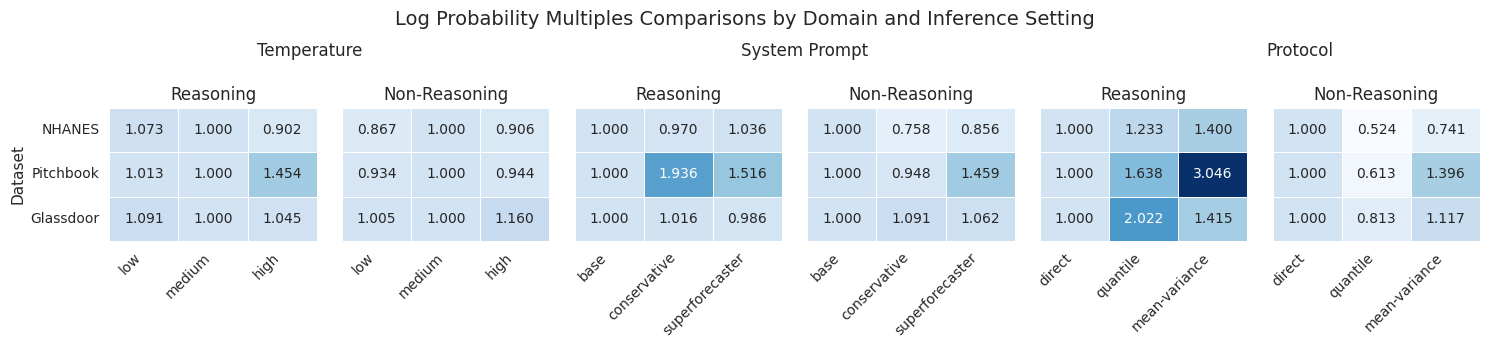

Data verification:
Temperature (Reasoning):
                low  medium      high
NHANES     1.072543     1.0  0.902147
Pitchbook  1.013250     1.0  1.454278
Glassdoor  1.091145     1.0  1.045016

Temperature (Non-Reasoning):
                low  medium      high
NHANES     0.867309     1.0  0.906208
Pitchbook  0.933622     1.0  0.944198
Glassdoor  1.005482     1.0  1.160030

System Prompt (Reasoning):
           base  conservative  superforecaster
NHANES      1.0      0.970155         1.035648
Pitchbook   1.0      1.936063         1.515556
Glassdoor   1.0      1.016111         0.986477

System Prompt (Non-Reasoning):
           base  conservative  superforecaster
NHANES      1.0      0.757880         0.855551
Pitchbook   1.0      0.947526         1.459413
Glassdoor   1.0      1.091300         1.061802

Protocol (Reasoning):
           direct  quantile  mean-variance
NHANES        1.0  1.233046       1.399555
Pitchbook     1.0  1.638309       3.045875
Glassdoor     1.0  2.021943       

In [9]:
defaults = {
    'model': 'o4-mini',
    'sysprompt': 'base',
    'protocol': 'direct',
    'temperature': 'medium'
}

def compute_logprob_multiples(logprob_data):  
    """Fixed version that returns a dictionary of all ablation results"""
    results = {}
    
    for ablation_type, df in logprob_data.items():
        if ablation_type not in defaults:
            continue
        reference_value = df[df['group'] == defaults[ablation_type]]['logprob_mean'].iloc[0]
        logprob_multiples_data = []
        for i, key in df.iterrows():
            logprob_multiples_data.append({'group': key['group'], 'multiple': np.exp(reference_value) / np.exp(key['logprob_mean'])})
        logprob_multiples = pd.DataFrame(logprob_multiples_data)
        
        # Convert to dictionary for easy access
        multiples_dict = dict(zip(logprob_multiples['group'], logprob_multiples['multiple']))
        results[ablation_type] = multiples_dict
        
        print(ablation_type)
        print(logprob_multiples)
        print('\n')
    
    return results

def compute_and_extract_logprob_multiples(logprob_data, dataset_name, reasoning_type):
    """Compute logprob multiples and extract specific ablation results."""
    print(f"{dataset_name}")
    print(f"{reasoning_type}")
    
    multiples = compute_logprob_multiples(logprob_data)
    
    return {
        'sysprompt': multiples.get('sysprompt'),
        'protocol': multiples.get('protocol'), 
        'temperature': multiples.get('temperature')
    }

# Define datasets and their corresponding logprob data
datasets = {
    'GLASSDOOR': {
        'reasoning': glass_logprob_r,
        'regular': glass_logprob_nr
    },
    'PITCHBOOK': {
        'reasoning': pitch_logprob_r,
        'regular': pitch_logprob_nr
    },
    'NHANES': {
        'reasoning': nhanes_logprob_r,
        'regular': nhanes_logprob_nr
    }
}

# Compute all logprob multiples
logprob_results = {}
for dataset_name, data in datasets.items():
    logprob_results[dataset_name] = {}
    for reasoning_type, logprob_data in data.items():
        logprob_results[dataset_name][reasoning_type] = compute_and_extract_logprob_multiples(
            logprob_data, dataset_name, reasoning_type.capitalize()
        )

# Now add your heatmap visualization code
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data = logprob_results.copy()
print(data.keys())

def create_dataframe_from_data(ablation_type, reasoning_type):
    """Create DataFrame for a specific ablation type and reasoning type"""
    datasets = ['NHANES', 'PITCHBOOK', 'GLASSDOOR']  # Use uppercase to match keys
    
    # Define variant orders to match the reference image
    variant_orders = {
        'temperature': ['low', 'medium', 'high'],
        'sysprompt': ['base', 'conservative', 'superforecaster'], 
        'protocol': ['direct', 'quantile', 'mean-variance']
    }
    
    variant_order = variant_orders[ablation_type]
    heatmap_data = []
    
    for dataset in datasets:
        row_data = []
        dataset_key = dataset
        
        # Check if data exists and is not None
        if (dataset_key in data and 
            reasoning_type in data[dataset_key] and 
            data[dataset_key][reasoning_type] is not None and
            ablation_type in data[dataset_key][reasoning_type] and
            data[dataset_key][reasoning_type][ablation_type] is not None):
            
            variant_dict = data[dataset_key][reasoning_type][ablation_type]
            
            for variant in variant_order:
                value = variant_dict.get(variant, np.nan)
                row_data.append(value)
        else:
            # Fill with NaN if data doesn't exist
            row_data = [np.nan] * len(variant_order)
            print(f"Warning: No data for {dataset} {reasoning_type} {ablation_type}")
            
        heatmap_data.append(row_data)
    
    df = pd.DataFrame(heatmap_data, 
                     index=['NHANES', 'Pitchbook', 'Glassdoor'],  # Display names
                     columns=variant_order)
    return df

# Create all the dataframes
temp_r = create_dataframe_from_data('temperature', 'reasoning')
temp_nr = create_dataframe_from_data('temperature', 'regular')
sp_r = create_dataframe_from_data('sysprompt', 'reasoning') 
sp_nr = create_dataframe_from_data('sysprompt', 'regular')
prot_r = create_dataframe_from_data('protocol', 'reasoning')
prot_nr = create_dataframe_from_data('protocol', 'regular')

# Shared color scale across all six heatmaps
all_vals = pd.concat([
    temp_r.stack(), temp_nr.stack(),
    sp_r.stack(),   sp_nr.stack(),
    prot_r.stack(), prot_nr.stack()
]).dropna()

vmin, vmax = (all_vals.min(), all_vals.max()) if len(all_vals) > 0 else (0, 1)

# Use reversed monochrome blue colormap (lower values = more blue)
monochrome = plt.cm.Blues

def draw(ax, df, title, xlabel, show_y=False, show_xlabel=True):
    """Draw heatmap with formatting matching the reference"""
    sns.heatmap(df, ax=ax, cmap=monochrome, vmin=vmin, vmax=vmax,
                annot=True, fmt='.3f', cbar=False, linewidths=0.5)
    ax.set_title(title)
    if show_xlabel:
        ax.set_xlabel(xlabel)
    else:
        ax.set_xlabel('')
    if show_y:
        ax.set_ylabel('Dataset')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # horizontal y-labels
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # tilted x-labels

# Single row with section labels
fig, axes = plt.subplots(1, 6, figsize=(15, 3.5))

draw(axes[0], temp_r,  'Reasoning',     '', show_y=True, show_xlabel=False)
draw(axes[1], temp_nr, 'Non-Reasoning', '', show_xlabel=False)
draw(axes[2], sp_r,    'Reasoning',     '', show_xlabel=False)
draw(axes[3], sp_nr,   'Non-Reasoning', '', show_xlabel=False)
draw(axes[4], prot_r,  'Reasoning',     '', show_xlabel=False)
draw(axes[5], prot_nr, 'Non-Reasoning', '', show_xlabel=False)

# Add main title and section labels
fig.suptitle('Log Probability Multiples Comparisons by Domain and Inference Setting', 
             fontsize=14, y=0.98)

fig.text(0.21, 0.85, 'Temperature', ha='center', fontsize=12)      
fig.text(0.54, 0.85, 'System Prompt', ha='center', fontsize=12)     
fig.text(0.87, 0.85, 'Protocol', ha='center', fontsize=12)        

plt.tight_layout()
plt.subplots_adjust(top=0.70)
plt.show()

# Print data summary for verification
print("Data verification:")
print("=" * 50)
print(f"Temperature (Reasoning):\n{temp_r}\n")
print(f"Temperature (Non-Reasoning):\n{temp_nr}\n")
print(f"System Prompt (Reasoning):\n{sp_r}\n")
print(f"System Prompt (Non-Reasoning):\n{sp_nr}\n")
print(f"Protocol (Reasoning):\n{prot_r}\n")
print(f"Protocol (Non-Reasoning):\n{prot_nr}\n")
print(f"Color scale range: {vmin:.3f} to {vmax:.3f}")

# Combined Plot focused on Direct Protocol

In [29]:
error_subplots['protocol']['reasoning']
prot_r

,direct,quantile,mean-variance
NHANES,1.0,1.233046,1.399555
Pitchbook,1.0,1.638309,3.045875
Glassdoor,1.0,2.021943,1.415396


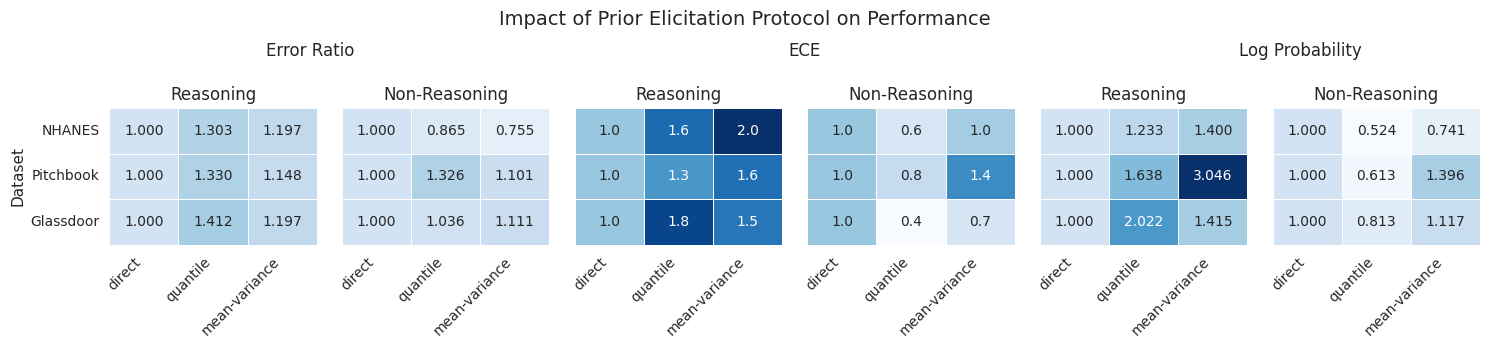

Data verification:
Temperature (Reasoning):
                low  medium      high
NHANES     1.072543     1.0  0.902147
Pitchbook  1.013250     1.0  1.454278
Glassdoor  1.091145     1.0  1.045016

Temperature (Non-Reasoning):
                low  medium      high
NHANES     0.867309     1.0  0.906208
Pitchbook  0.933622     1.0  0.944198
Glassdoor  1.005482     1.0  1.160030

System Prompt (Reasoning):
           base  conservative  superforecaster
NHANES      1.0      0.970155         1.035648
Pitchbook   1.0      1.936063         1.515556
Glassdoor   1.0      1.016111         0.986477

System Prompt (Non-Reasoning):
           base  conservative  superforecaster
NHANES      1.0      0.757880         0.855551
Pitchbook   1.0      0.947526         1.459413
Glassdoor   1.0      1.091300         1.061802

Protocol (Reasoning):
           direct  quantile  mean-variance
NHANES        1.0  1.233046       1.399555
Pitchbook     1.0  1.638309       3.045875
Glassdoor     1.0  2.021943       

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(15, 3.5))

draw(axes[0], error_subplots['protocol']['reasoning'],  'Reasoning',     '', show_y=True, show_xlabel=False)
draw(axes[1], error_subplots['protocol']['non_reasoning'], 'Non-Reasoning', '', show_xlabel=False)
draw_ece(axes[2], prot_r_ece,  'Reasoning',     '', show_xlabel=False)
draw_ece(axes[3], prot_nr_ece, 'Non-Reasoning', '', show_xlabel=False)
draw(axes[4], prot_r,  'Reasoning',     '', show_xlabel=False)
draw(axes[5], prot_nr, 'Non-Reasoning', '', show_xlabel=False)

# Add main title and section labels
fig.suptitle('Impact of Prior Elicitation Protocol on Performance', 
             fontsize=14, y=0.98)

fig.text(0.21, 0.85, 'Error Ratio', ha='center', fontsize=12)      
fig.text(0.54, 0.85, 'ECE', ha='center', fontsize=12)     
fig.text(0.87, 0.85, 'Log Probability', ha='center', fontsize=12)        

plt.tight_layout()
plt.subplots_adjust(top=0.70)
plt.show()

# Print data summary for verification
print("Data verification:")
print("=" * 50)
print(f"Temperature (Reasoning):\n{temp_r}\n")
print(f"Temperature (Non-Reasoning):\n{temp_nr}\n")
print(f"System Prompt (Reasoning):\n{sp_r}\n")
print(f"System Prompt (Non-Reasoning):\n{sp_nr}\n")
print(f"Protocol (Reasoning):\n{prot_r}\n")
print(f"Protocol (Non-Reasoning):\n{prot_nr}\n")
print(f"Color scale range: {vmin:.3f} to {vmax:.3f}")

Vmin 0.5240104273704576
Vmax 3.0458753183945313
Vmin 0.5240104273704576
Vmax 3.0458753183945313
Vmin ece 0.3861386138613862
Vmax ece 1.9667559476918233
Vmin ece 0.3861386138613862
Vmax ece 1.9667559476918233
Vmin 0.5240104273704576
Vmax 3.0458753183945313
Vmin 0.5240104273704576
Vmax 3.0458753183945313


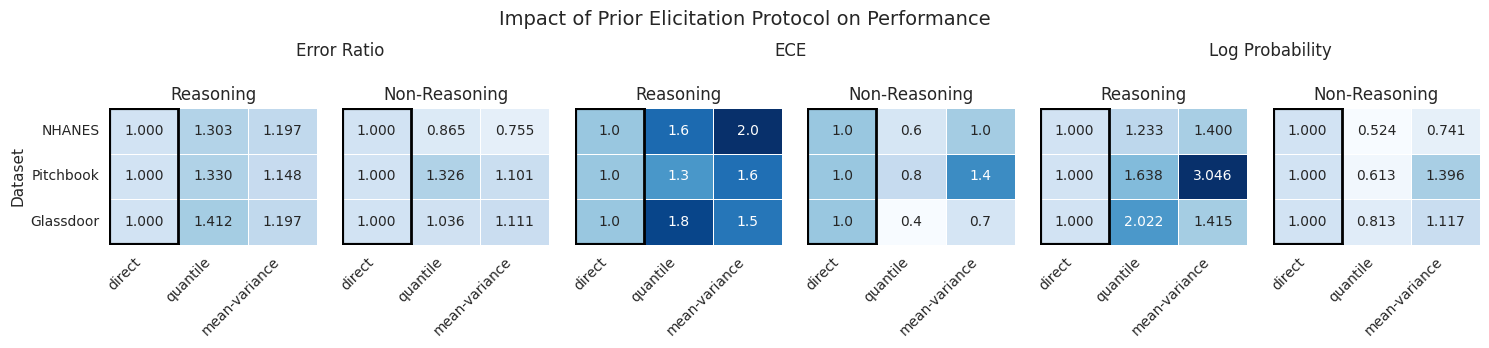

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Modified draw function with proper border using lines
def draw(ax, df, title, xlabel, show_y=False, show_xlabel=True, highlight_direct=False):
    """Draw heatmap with formatting matching the reference"""
    print("Vmin", vmin)
    print("Vmax", vmax)
    sns.heatmap(df, ax=ax, cmap=monochrome, vmin=vmin, vmax=vmax,
                annot=True, fmt='.3f', cbar=False, linewidths=0.5)
    ax.set_title(title)
    if show_xlabel:
        ax.set_xlabel(xlabel)
    else:
        ax.set_xlabel('')
    if show_y:
        ax.set_ylabel('Dataset')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # horizontal y-labels
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # tilted x-labels
    
    # Add black border around 'direct' column (first column)
    if highlight_direct:
        # Draw four lines to create a complete border around the first column
        # Left vertical line
        ax.plot([0, 0], [0, len(df)], color='black', linewidth=3)
        # Right vertical line (thinner to account for overlap)
        ax.plot([1, 1], [0, len(df)], color='black', linewidth=2)
        # Top horizontal line
        ax.plot([0, 1], [0, 0], color='black', linewidth=3)
        # Bottom horizontal line
        ax.plot([0, 1], [len(df), len(df)], color='black', linewidth=3)

# Modified draw_ece function with proper border using lines
def draw_ece(ax, df, title, xlabel, show_y=False, show_xlabel=True, highlight_direct=False):

    sns.heatmap(df, ax=ax, cmap=monochrome, vmin=vmin, vmax=vmax,
                annot=True, fmt='.1f', cbar=False, linewidths=0.5)  # fmt='.1f' for ECE values
    ax.set_title(title)
    if show_xlabel:
        ax.set_xlabel(xlabel)
    else:
        ax.set_xlabel('')
    if show_y:
        ax.set_ylabel('Dataset')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Add black border around 'direct' column (first column)
    if highlight_direct:
        # Draw four lines to create a complete border around the first column
        # Left vertical line
        ax.plot([0, 0], [0, len(df)], color='black', linewidth=3)
        # Right vertical line (thinner to account for overlap)
        ax.plot([1, 1], [0, len(df)], color='black', linewidth=2)
        # Top horizontal line
        ax.plot([0, 1], [0, 0], color='black', linewidth=3)
        # Bottom horizontal line
        ax.plot([0, 1], [len(df), len(df)], color='black', linewidth=3)

fig, axes = plt.subplots(1, 6, figsize=(15, 3.5))

draw(axes[0], error_subplots['protocol']['reasoning'], 'Reasoning', '', show_y=True, show_xlabel=False, highlight_direct=True)
draw(axes[1], error_subplots['protocol']['non_reasoning'], 'Non-Reasoning', '', show_xlabel=False, highlight_direct=True)
draw_ece(axes[2], prot_r_ece, 'Reasoning', '', show_xlabel=False, highlight_direct=True)
draw_ece(axes[3], prot_nr_ece, 'Non-Reasoning', '', show_xlabel=False, highlight_direct=True)
draw(axes[4], prot_r, 'Reasoning', '', show_xlabel=False, highlight_direct=True)
draw(axes[5], prot_nr, 'Non-Reasoning', '', show_xlabel=False, highlight_direct=True)

# Add main title and section labels
fig.suptitle('Impact of Prior Elicitation Protocol on Performance', 
             fontsize=14, y=0.98)

fig.text(0.23, 0.85, 'Error Ratio', ha='center', fontsize=12)      
fig.text(0.53, 0.85, 'ECE', ha='center', fontsize=12)     
fig.text(0.85, 0.85, 'Log Probability', ha='center', fontsize=12)        

plt.tight_layout()
plt.subplots_adjust(top=0.70)
plt.show()